In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

In [42]:
import pandas as pd
from rdkit.Chem import PandasTools

df = pd.read_csv(DATA_PROCESSED / "egfr_clean.csv")
PandasTools.AddMoleculeColumnToFrame(df, smilesCol="Clean Smiles", molCol="RDkit Mol", includeFingerprints=True)

Add common descriptors to the table

In [45]:
from rdkit.Chem import Descriptors, QED

desc_funcs = {
    "Molecular Weight": Descriptors.MolWt,
    "cLogP": Descriptors.MolLogP,
    "Polar Surface Area": Descriptors.TPSA,
    "Hydrogen Bond Donors": Descriptors.NumHDonors,
    "Hydrogen Bond Acceptors": Descriptors.NumHAcceptors,
    "Num Rotatable Bonds": Descriptors.NumRotatableBonds,
    "Heavy Atoms": Descriptors.HeavyAtomCount,
    "Aromatic Rings": Descriptors.NumAromaticRings,
    "QED": QED.qed,
}

for col, fun in desc_funcs.items():
    df[col] = df["RDkit Mol"].apply(fun)

In [46]:
df.columns

Index(['Clean InchiKey', 'Clean Smiles', 'Molecule ChEMBL ID', 'Acrylamide',
       'median', 'std', 'count', 'RDkit Mol', 'Molecular Weight', 'cLogP',
       'Num Rotatable Bonds', 'Polar Surface Area', 'Hydrogen Bond Donors',
       'Hydrogen Bond Acceptors', 'Heavy Atoms', 'Aromatic Rings', 'QED'],
      dtype='str')

Make a plot of the descriptor distributions.

C:\Users\lauren\AppData\Local\Temp\ipykernel_25952\3531821895.py:14: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


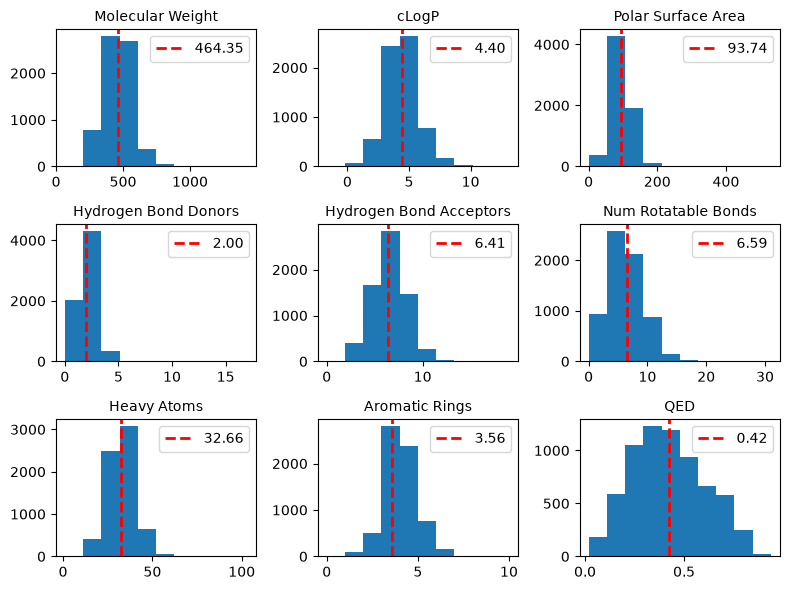

In [61]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(3,3, layout='constrained', figsize=(8,6))

for ax, col in zip(axs.flatten(), desc_funcs.keys()):
    ax.hist(df[col])
    ax.set_title(col, fontsize=10)

    mean_val = np.mean(df[col])
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'{mean_val:.2f}')
    ax.legend(fontsize=10)

fig.tight_layout()